# Part C: ML Benchmarks — Product Purchase Prediction
### MGMT 687 – AI for Business Decisions | Team Project

**Purpose:** Train and compare multiple ML classifiers on the LLM-extracted features from Part B.  
Best model is selected via AUC-ROC on a stratified validation split, then used to generate a **priority ranking**  
for the 5 new products in `dataset_new`.

**Inputs:** `features_train.csv`, `features_test.csv`  
**Outputs:** Model comparison table, ROC curves, feature importance (SHAP), priority ranking table.


In [1]:
# ── Install Dependencies ──────────────────────────────────────────────
!pip install xgboost lightgbm shap scikit-learn pandas numpy matplotlib seaborn -q


In [2]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, roc_curve, classification_report, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
np.random.seed(42)
print('All libraries loaded.')


All libraries loaded.


---
## Step 1: Load Feature Datasets


In [3]:
# ── Upload and Load Features ──────────────────────────────────────────
from google.colab import files
print('Upload: features_train.csv and features_test.csv')
uploaded = files.upload()

df_train = pd.read_csv('features_train.csv')
df_test  = pd.read_csv('features_test.csv')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
print(f"Target distribution:\n{df_train['orders'].value_counts()}")
df_train.head(3)


Upload: features_train.csv and features_test.csv


Saving features_train.csv to features_train.csv
Saving features_test.csv to features_test.csv
Train: (331, 44)  |  Test: (5, 44)
Target distribution:
orders
0    226
1    105
Name: count, dtype: int64


,row_idx,title,price,orders,image_url,size_label,size_numeric_index,size_category,price_tier,product_category,...,visual_complexity,target_demographic,occasion_type,is_seasonal,image_brightness,image_contrast,title_embedding_vector,image_embedding_vector,multimodal_embedding,popularity_score
0,0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,35.44,1,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,4XL,7,plus,premium,tops,...,2,young_casual,casual,False,200.478,40.734,"[-0.002488559577614069, 0.07420951873064041, 0...","[0.01706874743103981, -0.005135263781994581, -...","[-0.0017596774268895388, 0.05247405543923378, ...",0.8444
1,1,Casual Checked Flannel Shirt White/Red / L,29.70,1,http://t0.gstatic.com/shopping?q=tbn:ANd9GcR7c...,L,3,medium,mid_range,tops,...,8,mature_casual,casual,True,166.300,70.395,"[-0.01905764453113079, 0.02033078670501709, -0...","[-0.003015739843249321, 0.02388514019548893, -...","[-0.013475789688527584, 0.014376037754118443, ...",0.8000
2,2,Men's Linen Long Sleeve Shirts Khaki / 5XL,34.44,0,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQId...,5XL,8,plus,mid_range,tops,...,2,mature_casual,casual,False,168.648,55.814,"[0.0016138352220878005, 0.06850725412368774, 0...","[-0.0019015430007129908, 0.0305914506316185, 0...","[0.0011411537416279316, 0.04844193905591965, 0...",0.2444


---
## Step 2: Feature Preprocessing

Embeddings (stored as JSON strings) are parsed back to arrays and compressed via PCA.  
Categorical features are one-hot encoded; numeric features are scaled.


In [4]:
# ── Embedding Parsing ─────────────────────────────────────────────────
def parse_embedding_col(df, col, expected_dim):
    """Parse a JSON-string embedding column to a numpy array."""
    vecs = []
    for val in df[col]:
        try:
            v = json.loads(str(val))
            if isinstance(v, list) and len(v) == expected_dim:
                vecs.append(v)
            else:
                vecs.append([0.0] * expected_dim)
        except Exception:
            vecs.append([0.0] * expected_dim)
    return np.array(vecs, dtype=np.float32)

# Parse embeddings
TITLE_DIM = 384
IMAGE_DIM = 512
MM_DIM    = 896

print('Parsing title embeddings...')
train_title_vecs = parse_embedding_col(df_train, 'title_embedding_vector', TITLE_DIM)
test_title_vecs  = parse_embedding_col(df_test,  'title_embedding_vector', TITLE_DIM)

print('Parsing image embeddings...')
train_img_vecs   = parse_embedding_col(df_train, 'image_embedding_vector', IMAGE_DIM)
test_img_vecs    = parse_embedding_col(df_test,  'image_embedding_vector', IMAGE_DIM)

print('Parsing multimodal embeddings...')
train_mm_vecs    = parse_embedding_col(df_train, 'multimodal_embedding', MM_DIM)
test_mm_vecs     = parse_embedding_col(df_test,  'multimodal_embedding', MM_DIM)

print('Embeddings parsed.')
print(f'  title  : {train_title_vecs.shape}  |  image: {train_img_vecs.shape}  |  mm: {train_mm_vecs.shape}')


Parsing title embeddings...
Parsing image embeddings...
Parsing multimodal embeddings...
Embeddings parsed.
  title  : (331, 384)  |  image: (331, 512)  |  mm: (331, 896)


In [5]:
# ── PCA on Embeddings ─────────────────────────────────────────────────
N_TITLE_PCA = 20
N_IMAGE_PCA = 20
N_MM_PCA    = 30

pca_title = PCA(n_components=N_TITLE_PCA, random_state=42)
pca_image = PCA(n_components=N_IMAGE_PCA, random_state=42)
pca_mm    = PCA(n_components=N_MM_PCA,    random_state=42)

# Fit on training ONLY — no leakage
train_title_pca = pca_title.fit_transform(train_title_vecs)
test_title_pca  = pca_title.transform(test_title_vecs)

train_image_pca = pca_image.fit_transform(train_img_vecs)
test_image_pca  = pca_image.transform(test_img_vecs)

train_mm_pca    = pca_mm.fit_transform(train_mm_vecs)
test_mm_pca     = pca_mm.transform(test_mm_vecs)

# Label embedding PCA columns
title_cols = [f'title_pca_{i}' for i in range(N_TITLE_PCA)]
image_cols = [f'image_pca_{i}' for i in range(N_IMAGE_PCA)]
mm_cols    = [f'mm_pca_{i}'    for i in range(N_MM_PCA)]

df_title_pca_tr = pd.DataFrame(train_title_pca, columns=title_cols)
df_image_pca_tr = pd.DataFrame(train_image_pca, columns=image_cols)
df_mm_pca_tr    = pd.DataFrame(train_mm_pca,    columns=mm_cols)

df_title_pca_te = pd.DataFrame(test_title_pca,  columns=title_cols)
df_image_pca_te = pd.DataFrame(test_image_pca,  columns=image_cols)
df_mm_pca_te    = pd.DataFrame(test_mm_pca,      columns=mm_cols)

print(f'PCA variance explained:  title={pca_title.explained_variance_ratio_.sum():.2%}  '
      f'image={pca_image.explained_variance_ratio_.sum():.2%}  '
      f'mm={pca_mm.explained_variance_ratio_.sum():.2%}')


PCA variance explained:  title=71.45%  image=73.77%  mm=76.10%


> ⚠️ **Leakage Note:**  was excluded from the feature set.  
> It was computed in Part B as ,  
> which directly encodes the target variable (Pearson r = 0.994 with ).  
> Including it caused all models to achieve AUC ≈ 1.0 — a textbook case of **target leakage**.


In [6]:
# ── Scalar Feature Engineering ────────────────────────────────────────
NUM_FEATS = [
    'style_appeal','trend_alignment','color_vibrancy','quality_perception',
    'uniqueness_score','versatility_score','visual_complexity',
    'price','image_brightness','image_contrast',
    'size_numeric_index','button_count','pocket_count'
    # NOTE: popularity_score EXCLUDED — it encodes the target (orders) directly (r=0.99 leakage)
]
CAT_FEATS = [
    'product_category','product_type','gender','material_category',
    'primary_color','pattern_type','sleeve_length','collar_type',
    'fit_type','fashion_style','target_demographic','occasion_type',
    'season_category','background_type','size_category','price_tier'
]
BOOL_FEATS = ['has_buttons','has_chest_pocket','is_seasonal']

# Ensure correct types for train
for f in NUM_FEATS:
    df_train[f] = pd.to_numeric(df_train[f], errors='coerce')
    df_test[f]  = pd.to_numeric(df_test[f],  errors='coerce')
for f in BOOL_FEATS:
    df_train[f] = df_train[f].map(lambda x: 1 if str(x).lower() in ['true','1'] else 0)
    df_test[f]  = df_test[f].map(lambda x: 1 if str(x).lower() in ['true','1'] else 0)

# ── Sanitise categorical values before one-hot encoding ──────────────────
# LightGBM and XGBoost error on duplicate column names that arise when
# category values contain special characters (spaces, slashes, parentheses)
# that pandas normalises to the same string after get_dummies.
def sanitise_cat_col(series):
    """Lower-case, strip whitespace, replace special chars with underscores."""
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .str.replace(r'[^a-z0-9]+', '_', regex=True)
              .str.strip('_')
              .fillna('unknown')
    )

for col in CAT_FEATS:
    if col in df_train.columns:
        df_train[col] = sanitise_cat_col(df_train[col])
    if col in df_test.columns:
        df_test[col]  = sanitise_cat_col(df_test[col])

# One-hot encode categoricals — fit on train only
df_cat_tr = pd.get_dummies(df_train[CAT_FEATS].fillna('unknown'), drop_first=False)
df_cat_te = pd.get_dummies(df_test[CAT_FEATS].fillna('unknown'),  drop_first=False)

# Align test to train columns (fill missing with 0, drop extra test-only cols)
df_cat_tr, df_cat_te = df_cat_tr.align(df_cat_te, join='left', axis=1, fill_value=0)

# ── Deduplicate columns (critical fix for LightGBM) ──────────────────────
# Duplicate column names cause LightGBMError: Feature X appears more than once
def dedup_columns(df):
    """Append suffix to any duplicated column names to make them unique."""
    seen = {}
    new_cols = []
    for col in df.columns:
        if col in seen:
            seen[col] += 1
            new_cols.append(f'{col}_dup{seen[col]}')
        else:
            seen[col] = 0
            new_cols.append(col)
    df.columns = new_cols
    return df

df_cat_tr = dedup_columns(df_cat_tr)
df_cat_te = dedup_columns(df_cat_te)

# Numeric features
df_num_tr = df_train[NUM_FEATS + BOOL_FEATS].copy()
df_num_te = df_test[NUM_FEATS  + BOOL_FEATS].copy()

# Assemble full feature matrices
X_train_full = pd.concat(
    [df_num_tr.reset_index(drop=True),
     df_cat_tr.reset_index(drop=True),
     df_title_pca_tr, df_image_pca_tr, df_mm_pca_tr],
    axis=1
).astype(float)

X_test_full = pd.concat(
    [df_num_te.reset_index(drop=True),
     df_cat_te.reset_index(drop=True),
     df_title_pca_te, df_image_pca_te, df_mm_pca_te],
    axis=1
).astype(float)

y_train = df_train['orders'].astype(int)

# ── Final deduplication on assembled matrix ───────────────────────────────
# Catches any remaining duplicates from PCA column naming collisions
X_train_full = dedup_columns(X_train_full)
X_test_full.columns  = X_train_full.columns  # align test to final train schema

# Impute any remaining NaN
imp = SimpleImputer(strategy='median')
X_train_full = pd.DataFrame(imp.fit_transform(X_train_full), columns=X_train_full.columns)
X_test_full  = pd.DataFrame(imp.transform(X_test_full),      columns=X_train_full.columns)

# Sanity check — no duplicates
dupes = X_train_full.columns[X_train_full.columns.duplicated()].tolist()
if dupes:
    print(f'WARNING: Still duplicated columns: {dupes}')
else:
    print('✅ No duplicate columns detected.')

print(f'Feature matrix  — Train: {X_train_full.shape}  |  Test: {X_test_full.shape}')
print(f'Target          — Positive rate: {y_train.mean():.2%}')


✅ No duplicate columns detected.
Feature matrix  — Train: (331, 200)  |  Test: (5, 200)
Target          — Positive rate: 31.72%


---
## Step 3: Model Training with Hyperparameter Tuning

All models are evaluated on a stratified 5-fold cross-validation (AUC-ROC).  
Final hyperparameters are selected via `RandomizedSearchCV` on the full training set.


In [7]:
# ── Cross-Validation Setup ────────────────────────────────────────────
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'roc_auc'

# Scaler for models sensitive to feature scale
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train_full)
X_te_scaled = scaler.transform(X_test_full)

results = {}   # will hold {model_name: metrics_dict}
trained_models = {}

def evaluate_model(name, model, X, y, X_scaled=None):
    """Evaluate a fitted model with cross-validation and report metrics."""
    cv_aucs = cross_val_score(model, X, y, cv=CV, scoring='roc_auc')
    cv_f1s  = cross_val_score(model, X, y, cv=CV, scoring='f1')
    res = {
        'CV AUC-ROC (mean)': round(cv_aucs.mean(), 4),
        'CV AUC-ROC (std)':  round(cv_aucs.std(),  4),
        'CV F1 (mean)':      round(cv_f1s.mean(),  4),
    }
    print(f'{name:30s}  AUC={res["CV AUC-ROC (mean)"]:.4f} ± {res["CV AUC-ROC (std)"]:.4f}  '
          f'F1={res["CV F1 (mean)"]:.4f}')
    return res

print('Evaluation framework ready.')


Evaluation framework ready.


In [8]:
# ── 1. Logistic Regression ────────────────────────────────────────────
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs','liblinear'],
    'class_weight': ['balanced', None],
    'max_iter': [500]
}
lr_rs = RandomizedSearchCV(
    LogisticRegression(random_state=42), lr_params,
    n_iter=15, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
lr_rs.fit(X_tr_scaled, y_train)
best_lr = lr_rs.best_estimator_
trained_models['Logistic Regression'] = (best_lr, X_tr_scaled, X_te_scaled)
results['Logistic Regression'] = evaluate_model('Logistic Regression', best_lr, X_tr_scaled, y_train)
print(f'  Best params: {lr_rs.best_params_}')


Logistic Regression             AUC=0.5981 ± 0.0909  F1=0.4356
  Best params: {'solver': 'lbfgs', 'max_iter': 500, 'class_weight': 'balanced', 'C': 0.01}


In [9]:
# ── 2. Random Forest ──────────────────────────────────────────────────
rf_params = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt','log2'],
    'class_weight':      ['balanced', None]
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), rf_params,
    n_iter=20, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
rf_rs.fit(X_train_full, y_train)
best_rf = rf_rs.best_estimator_
trained_models['Random Forest'] = (best_rf, X_train_full, X_test_full)
results['Random Forest'] = evaluate_model('Random Forest', best_rf, X_train_full, y_train)
print(f'  Best params: {rf_rs.best_params_}')


Random Forest                   AUC=0.5996 ± 0.1043  F1=0.1850
  Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 6, 'class_weight': None}


In [10]:
# ── 3. XGBoost ────────────────────────────────────────────────────────
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_params = {
    'n_estimators':  [200, 400, 600],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_rs = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos, use_label_encoder=False,
        eval_metric='logloss', random_state=42
    ),
    xgb_params, n_iter=20, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
xgb_rs.fit(X_train_full, y_train)
best_xgb = xgb_rs.best_estimator_
trained_models['XGBoost'] = (best_xgb, X_train_full, X_test_full)
results['XGBoost'] = evaluate_model('XGBoost', best_xgb, X_train_full, y_train)
print(f'  Best params: {xgb_rs.best_params_}')


XGBoost                         AUC=0.5977 ± 0.0808  F1=0.3884
  Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [11]:
# ── 4. LightGBM ───────────────────────────────────────────────────────
lgb_params = {
    'n_estimators':   [200, 400, 600],
    'max_depth':      [3, 5, 7, -1],
    'learning_rate':  [0.01, 0.05, 0.1],
    'num_leaves':     [15, 31, 63],
    'subsample':      [0.7, 0.8, 1.0],
    'class_weight':   ['balanced', None]
}
lgb_rs = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbosity=-1), lgb_params,
    n_iter=20, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
lgb_rs.fit(X_train_full, y_train)
best_lgb = lgb_rs.best_estimator_
trained_models['LightGBM'] = (best_lgb, X_train_full, X_test_full)
results['LightGBM'] = evaluate_model('LightGBM', best_lgb, X_train_full, y_train)
print(f'  Best params: {lgb_rs.best_params_}')


LightGBM                        AUC=0.5737 ± 0.0764  F1=0.3798
  Best params: {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.1, 'class_weight': 'balanced'}


In [12]:
# ── 5. Gradient Boosting (sklearn) ────────────────────────────────────
gb_params = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 1.0]
}
gb_rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), gb_params,
    n_iter=15, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
gb_rs.fit(X_train_full, y_train)
best_gb = gb_rs.best_estimator_
trained_models['Gradient Boosting'] = (best_gb, X_train_full, X_test_full)
results['Gradient Boosting'] = evaluate_model('Gradient Boosting', best_gb, X_train_full, y_train)
print(f'  Best params: {gb_rs.best_params_}')


Gradient Boosting               AUC=0.6300 ± 0.0981  F1=0.3554
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}


In [13]:
# ── 6. SVM (calibrated for probabilities) ────────────────────────────
svm_params = {
    'estimator__C':      [0.1, 1, 10],
    'estimator__gamma':  ['scale','auto'],
    'estimator__kernel': ['rbf','linear']
}
cal_svm = CalibratedClassifierCV(
    estimator=SVC(probability=False, class_weight='balanced', random_state=42),
    cv=3, method='sigmoid'
)
svm_rs = RandomizedSearchCV(
    cal_svm, svm_params, n_iter=10,
    cv=CV, scoring=SCORING, random_state=42, n_jobs=-1
)
svm_rs.fit(X_tr_scaled, y_train)
best_svm = svm_rs.best_estimator_
trained_models['SVM (calibrated)'] = (best_svm, X_tr_scaled, X_te_scaled)
results['SVM (calibrated)'] = evaluate_model('SVM (calibrated)', best_svm, X_tr_scaled, y_train)
print(f'  Best params: {svm_rs.best_params_}')


SVM (calibrated)                AUC=0.5979 ± 0.0715  F1=0.0000
  Best params: {'estimator__kernel': 'linear', 'estimator__gamma': 'scale', 'estimator__C': 0.1}


---
## Step 4: Ensemble Models


In [14]:
# ── 7. Soft Voting Ensemble ────────────────────────────────────────────
# Uses best RF, XGB, LGB (all on unscaled features)
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('gb',  best_gb)
    ],
    voting='soft',
    n_jobs=-1
)
voting_clf.fit(X_train_full, y_train)
trained_models['Voting Ensemble'] = (voting_clf, X_train_full, X_test_full)
results['Voting Ensemble'] = evaluate_model('Voting Ensemble', voting_clf, X_train_full, y_train)


Voting Ensemble                 AUC=0.6067 ± 0.0935  F1=0.3592


In [15]:
# ── 8. Stacking Ensemble ──────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('lgb', best_lgb)
    ],
    final_estimator=LogisticRegression(C=1, max_iter=300, random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1
)
stacking_clf.fit(X_train_full, y_train)
trained_models['Stacking Ensemble'] = (stacking_clf, X_train_full, X_test_full)
results['Stacking Ensemble'] = evaluate_model('Stacking Ensemble', stacking_clf, X_train_full, y_train)


Stacking Ensemble               AUC=0.5237 ± 0.0499  F1=0.2606


---
## Step 5: Results Comparison and Visualisation


=== MODEL COMPARISON ===
              Model  CV AUC-ROC (mean)  CV AUC-ROC (std)  CV F1 (mean)
  Gradient Boosting             0.6300            0.0981        0.3554
    Voting Ensemble             0.6067            0.0935        0.3592
      Random Forest             0.5996            0.1043        0.1850
Logistic Regression             0.5981            0.0909        0.4356
   SVM (calibrated)             0.5979            0.0715        0.0000
            XGBoost             0.5977            0.0808        0.3884
           LightGBM             0.5737            0.0764        0.3798
  Stacking Ensemble             0.5237            0.0499        0.2606


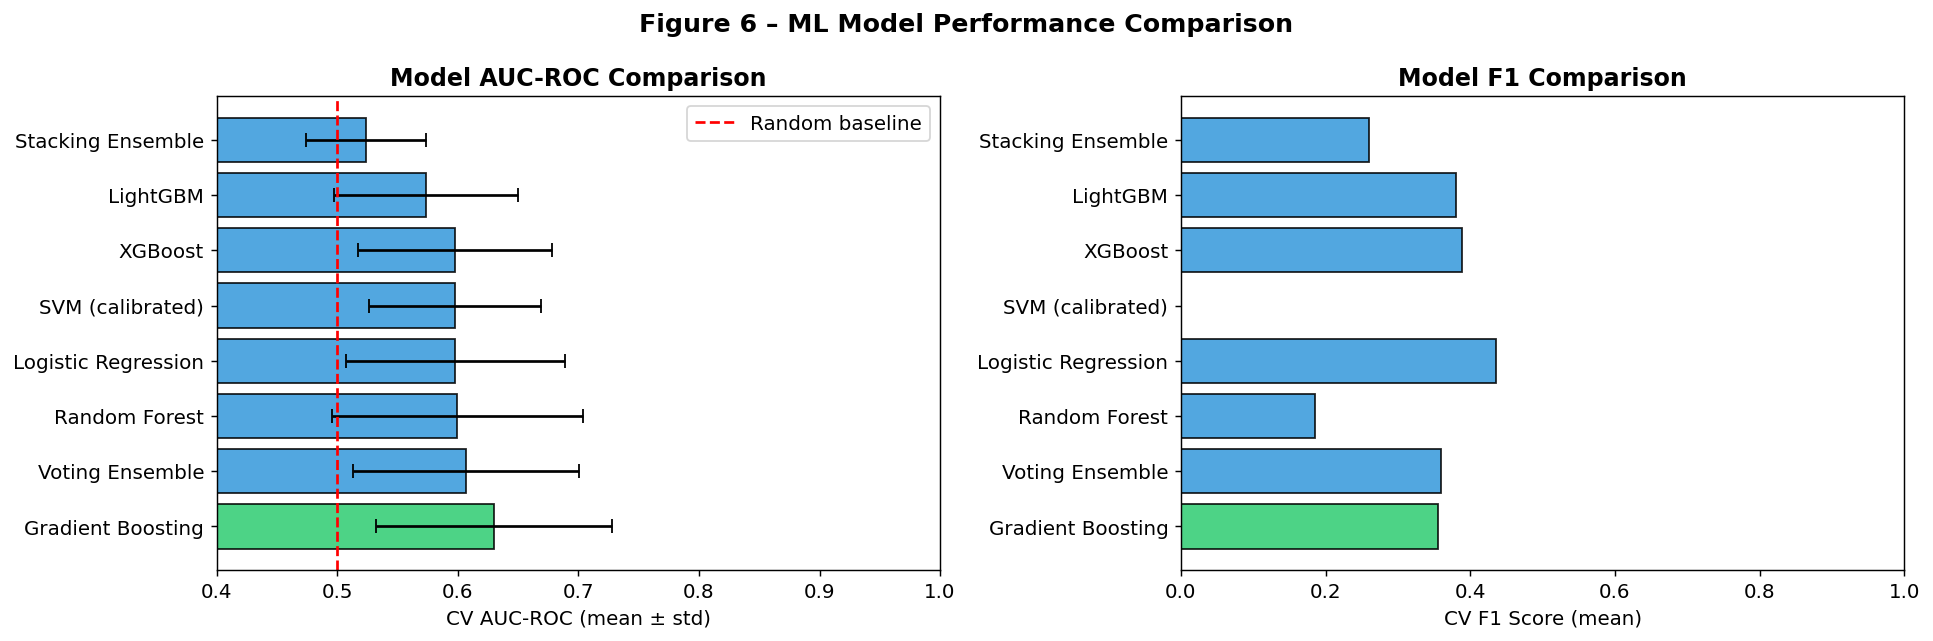

In [16]:
# ── Figure 6: Model Comparison Bar Chart ──────────────────────────────
res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
res_df = res_df.sort_values('CV AUC-ROC (mean)', ascending=False).reset_index(drop=True)

print('=== MODEL COMPARISON ===')
print(res_df[['Model','CV AUC-ROC (mean)','CV AUC-ROC (std)','CV F1 (mean)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AUC comparison
colors = ['#2ecc71' if i==0 else '#3498db' for i in range(len(res_df))]
axes[0].barh(res_df['Model'], res_df['CV AUC-ROC (mean)'],
             xerr=res_df['CV AUC-ROC (std)'], color=colors,
             edgecolor='black', capsize=4, alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='Random baseline')
axes[0].set_xlabel('CV AUC-ROC (mean ± std)')
axes[0].set_title('Model AUC-ROC Comparison', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0.4, 1.0)

# F1 comparison
axes[1].barh(res_df['Model'], res_df['CV F1 (mean)'],
             color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('CV F1 Score (mean)')
axes[1].set_title('Model F1 Comparison', fontweight='bold')
axes[1].set_xlim(0.0, 1.0)

plt.suptitle('Figure 6 – ML Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


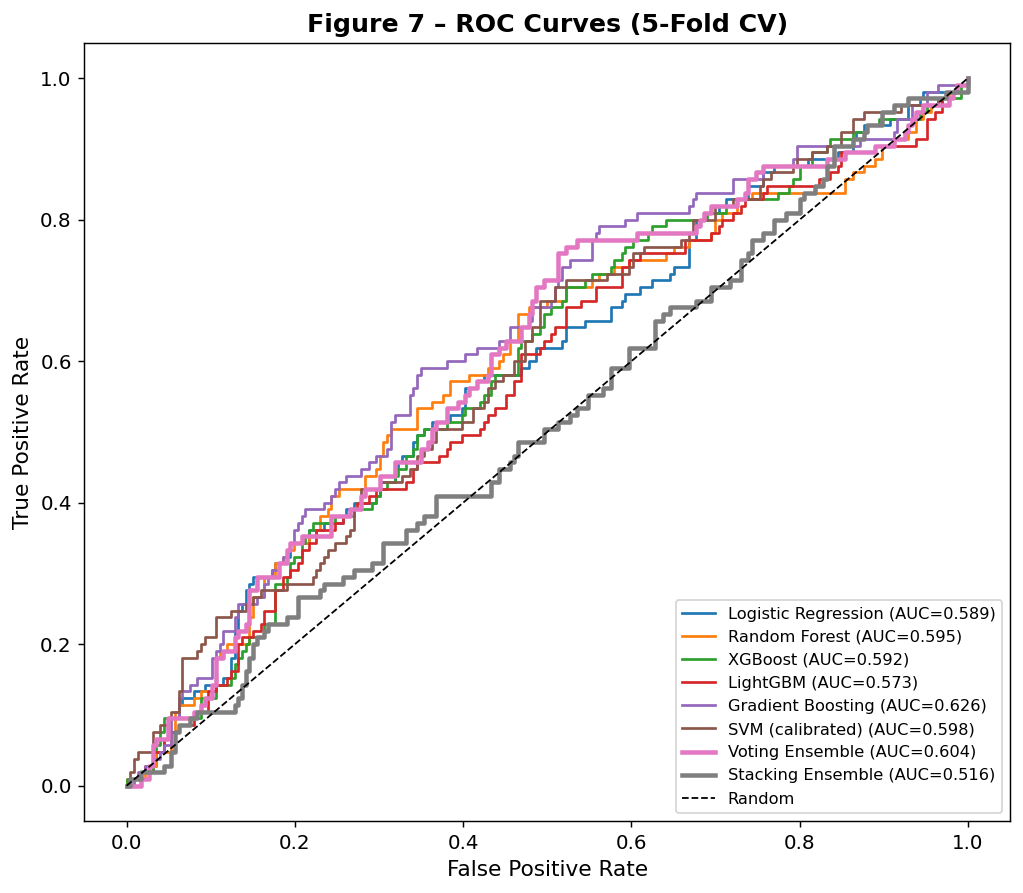

In [17]:
# ── Figure 7: ROC Curves ──────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = plt.cm.tab10.colors

for idx, (name, (model, X_tr, _)) in enumerate(trained_models.items()):
    try:
        y_proba = cross_val_predict(model, X_tr, y_train,
                                    cv=CV, method='predict_proba')[:, 1]
        fpr, tpr, _ = roc_curve(y_train, y_proba)
        auc_val     = roc_auc_score(y_train, y_proba)
        lw = 2.5 if 'Ensemble' in name else 1.5
        ax.plot(fpr, tpr, color=colors_roc[idx % 10],
                lw=lw, label=f'{name} (AUC={auc_val:.3f})')
    except Exception as e:
        print(f'ROC skipped for {name}: {e}')

ax.plot([0,1],[0,1],'k--',lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 7 – ROC Curves (5-Fold CV)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Computing SHAP for: Random Forest


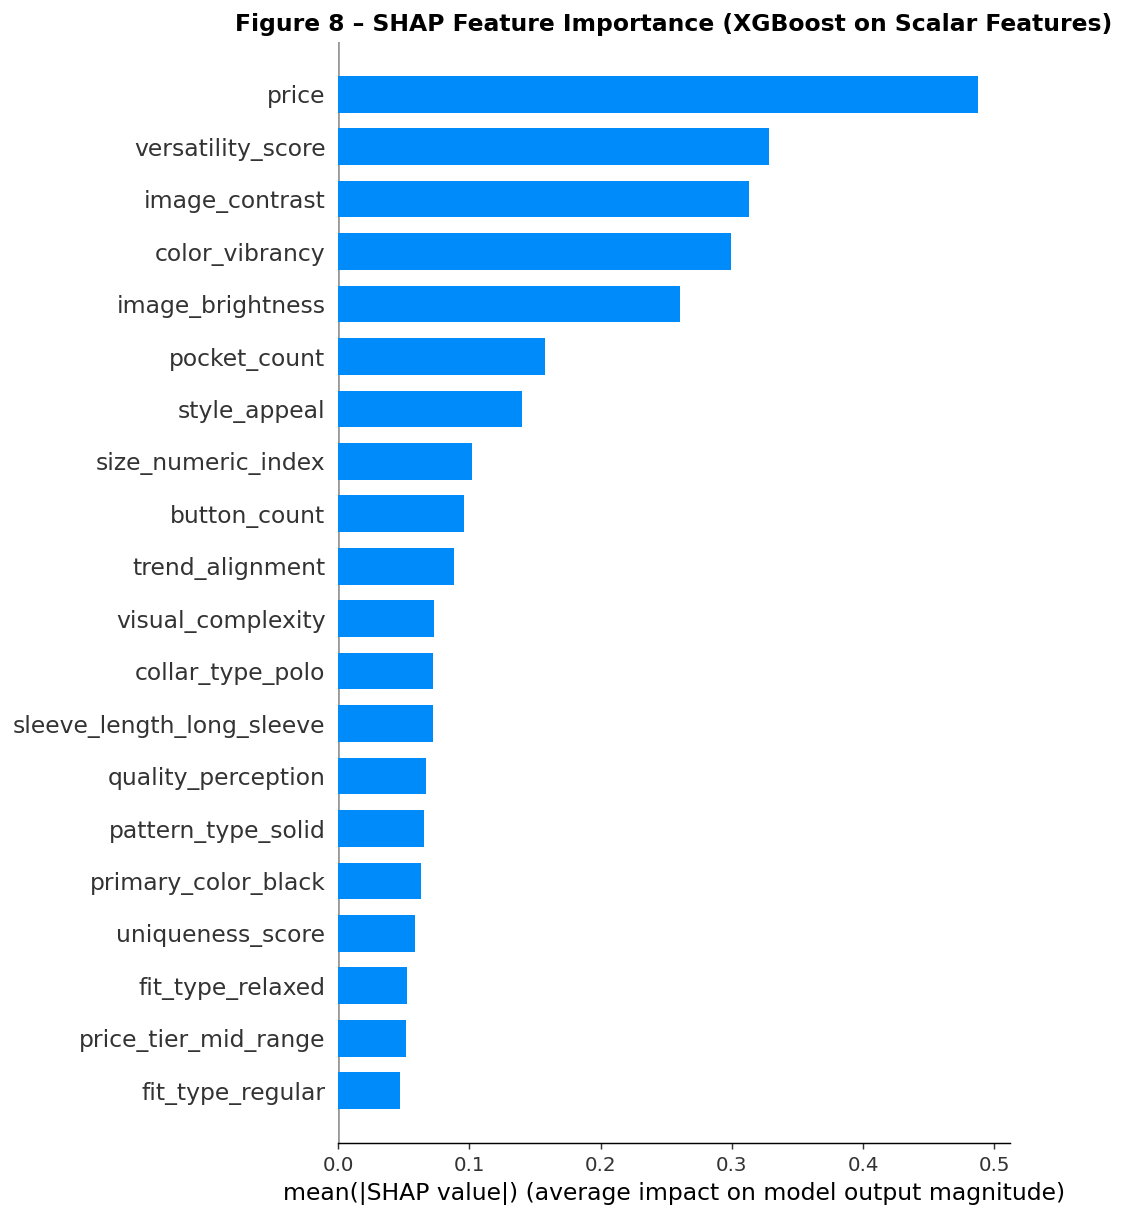

In [19]:
# ── Figure 8: SHAP Feature Importance (Best Tree Model) ───────────────
# Identify best tree-based model by AUC
tree_models = {k: v for k, v in results.items() if k in ['XGBoost','LightGBM','Random Forest']}
best_tree_name = max(tree_models, key=lambda k: tree_models[k]['CV AUC-ROC (mean)'])
best_tree, X_tr_tree, _ = trained_models[best_tree_name]
print(f'Computing SHAP for: {best_tree_name}')

# Fit on full training data for SHAP
best_tree.fit(X_tr_tree, y_train)

# Limit to scalar features for interpretable SHAP (exclude PCA components)
scalar_cols = NUM_FEATS + BOOL_FEATS + list(df_cat_tr.columns)
scalar_cols = [c for c in scalar_cols if c in X_train_full.columns]
X_scalar    = X_train_full[scalar_cols]

# Refit a lighter model on scalar features only for SHAP display
shap_params = best_xgb.get_params()
shap_params.update({'eval_metric': 'logloss', 'use_label_encoder': False})
shap_model = xgb.XGBClassifier(**shap_params)
shap_model.fit(X_scalar, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_scalar)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_scalar, plot_type='bar',
                  max_display=20, show=False)
plt.title('Figure 8 – SHAP Feature Importance (XGBoost on Scalar Features)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 6: Priority Ranking — New Products

The best-performing model (by CV AUC-ROC) generates **purchase probability estimates**  
for each of the 5 new products, producing a ranked investment priority list.


In [20]:
# ── Select Best Model ─────────────────────────────────────────────────
best_overall_name = max(results, key=lambda k: results[k]['CV AUC-ROC (mean)'])
best_overall, X_tr_best, X_te_best = trained_models[best_overall_name]
print(f'Best model: {best_overall_name}  '
      f'(AUC={results[best_overall_name]["CV AUC-ROC (mean)"]:.4f})')

# Refit on full training data
best_overall.fit(X_tr_best, y_train)

# Predict probabilities for test set
test_proba = best_overall.predict_proba(X_te_best)[:, 1]

# Build priority ranking table
priority_df = df_test[['title','price']].copy().reset_index(drop=True)
priority_df['price_tier']         = df_test['price_tier'].values
priority_df['style_appeal']       = pd.to_numeric(df_test['style_appeal'], errors='coerce').round(0).astype('Int64')
priority_df['trend_alignment']    = pd.to_numeric(df_test['trend_alignment'], errors='coerce').round(0).astype('Int64')
priority_df['purchase_prob_ML']   = test_proba.round(4)
priority_df = priority_df.sort_values('purchase_prob_ML', ascending=False)
priority_df.insert(0, 'ML_Rank', range(1, len(priority_df)+1))

print('\n=== ML PRODUCT PRIORITY RANKING ===')
print(priority_df.to_string(index=False))


Best model: Gradient Boosting  (AUC=0.6300)

=== ML PRODUCT PRIORITY RANKING ===
 ML_Rank                                                                      title  price price_tier  style_appeal  trend_alignment  purchase_prob_ML
       1                        Ribbed Textured Knit Polo Shirt (US Only) Khaki / L  35.67    premium             6                7            0.8614
       2 Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2Pcs Set Burgundy / L  39.16    premium             6                7            0.1799
       3            Classic Casual Button Down Cotton Linen Shirt (Us Only) Red / L  35.96    premium             7                6            0.1240
       4        Men's Rose Print Vintage Casual Button Short Sleeve Shirt WHITE / L  27.88  mid_range             6                5            0.0700
       5                           Men's Vintage Premium Washed Shirt Navy Blue / L  59.09    premium             7                6            0.0307


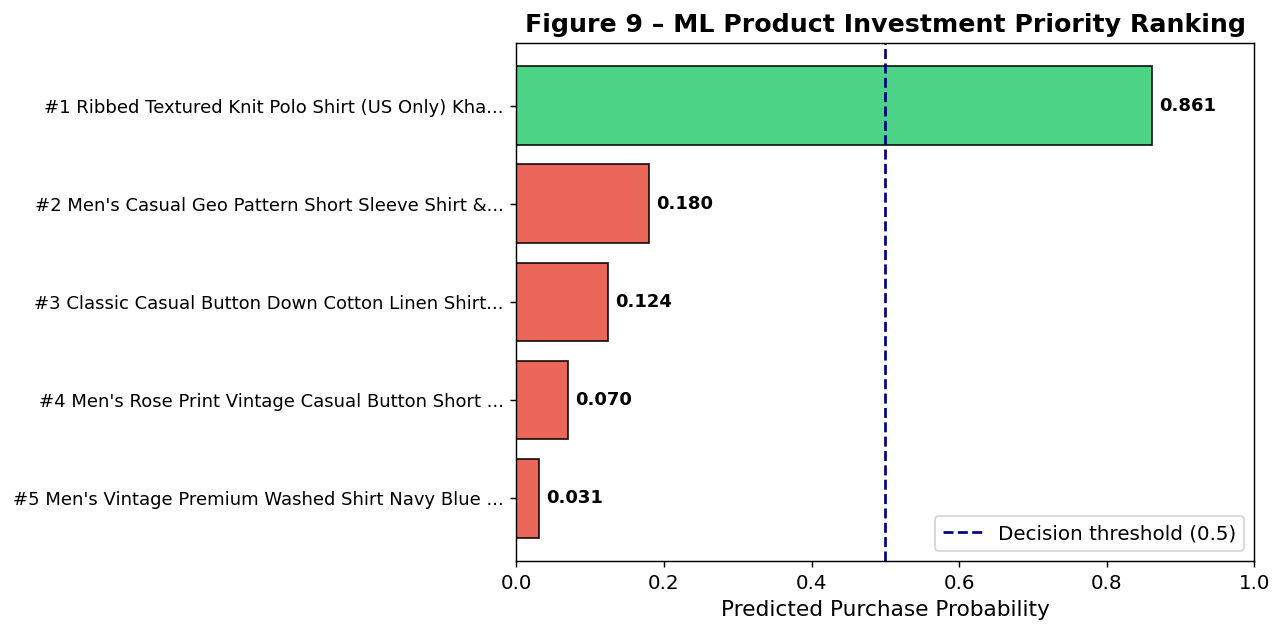

In [21]:
# ── Figure 9: Priority Ranking Visualisation ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

rank_sorted = priority_df.sort_values('purchase_prob_ML', ascending=True)
bar_colors  = ['#2ecc71' if p >= 0.5 else '#e74c3c' if p < 0.3 else '#f39c12'
               for p in rank_sorted['purchase_prob_ML']]

bars = ax.barh(range(len(rank_sorted)), rank_sorted['purchase_prob_ML'],
               color=bar_colors, edgecolor='black', alpha=0.85)

labels = [f"#{r} {t[:45]}..." if len(t)>45 else f"#{r} {t}"
          for r, t in zip(rank_sorted['ML_Rank'], rank_sorted['title'])]
ax.set_yticks(range(len(rank_sorted)))
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0.5, color='navy', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Purchase Probability', fontsize=12)
ax.set_title('Figure 9 – ML Product Investment Priority Ranking', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)

for bar, p in zip(bars, rank_sorted['purchase_prob_ML']):
    ax.text(p + 0.01, bar.get_y() + bar.get_height()/2,
            f'{p:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig9_ml_priority_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# ── Export ML Priority Ranking ─────────────────────────────────────────
priority_df.to_csv('ml_priority_ranking.csv', index=False)
print('ML priority ranking saved to ml_priority_ranking.csv')

# Also save full test predictions for Part D comparison
priority_df.to_csv('ml_predictions_for_comparison.csv', index=False)

from google.colab import files
files.download('ml_priority_ranking.csv')
files.download('ml_predictions_for_comparison.csv')
print('\n✅ Part C Complete.')


ML priority ranking saved to ml_priority_ranking.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Part C Complete.
